In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import uniform_filter, median_filter, gaussian_filter
from scipy import stats
from scipy.stats import norm
import pandas as pd

%matplotlib notebook

In [2]:
def parametric_map_interactive(para_array, mask_slice, spacing, parameter_name, cbar=True):
    para_map = np.zeros_like(mask_slice, dtype=float)
    para_map[mask_slice == 1] = para_array

    index_map = np.zeros_like(mask_slice, dtype=int)
    index_map[mask_slice == 1] = np.arange(len(para_array))
    
#     # --- START: Median Filtering ---
    
#     # Define the neighborhood size. 
#     # size=3 means a 3x3 kernel (looks at 8 neighbors).
#     # size=5 means a 5x5 kernel (stronger effect). Start with 3.
#     kernel_size = 2

#     # Apply the median filter
#     para_map = median_filter(para_map, size=kernel_size)
    
#     # Re-apply the original mask to ensure no values "bleed" into the background
#     para_map[mask_slice == 0] = 0.0
    
    # --- END: Median Filtering ---
    
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 8))

    # choose cmap and vmax/vmin as before…
    cmap = 'gray'
    if parameter_name == "Ki":
        vmax = 0.035; cmap = plt.cm.inferno
    elif parameter_name == "Ki Uncertainty":
        vmax = 0.12; cmap = plt.cm.inferno
    elif parameter_name == "Ki Posterior Std":
        vmax = 0.03; cmap = plt.cm.inferno
    elif parameter_name == "K_1":
        vmax = 0.9; cmap = plt.cm.inferno
    elif parameter_name == "Vb":
        vmax = np.max(para_map)
    elif parameter_name == "k_4":
        vmax = 0.125; cmap = plt.cm.inferno
    elif parameter_name == "k_2":
        vmax = 1.8; cmap = plt.cm.inferno
    elif parameter_name == "k_3":
        vmax = 0.3; cmap = plt.cm.inferno
    elif parameter_name == "EDT":
        vmax = 40
    elif parameter_name == "Patlak Ki":
        vmax = 0.02; cmap = plt.cm.inferno
    elif parameter_name == "Logan VT":
        vmax = 4
    elif parameter_name == "Coefficient of Variation":
        vmax = np.max(para_map); cmap = plt.cm.inferno
    elif parameter_name == "k4 Irreversibility":
        vmax = np.max(para_map)
        cmap = plt.cm.binary
    else:
        vmax = np.max(para_map)
    vmin = np.min(para_map)
    
    img_overlay = ax.imshow(
        para_map,
        cmap=cmap,
        alpha=1,
        aspect=spacing[1]/spacing[0], 
        vmax=vmax,
        vmin=vmin,
        interpolation='nearest'
    )
    img_overlay.set_clim(0, vmax)
    plt.axis('off')
    ax.invert_yaxis()

    if cbar:
        cbar = plt.colorbar(img_overlay, ax=ax, orientation='vertical')
        cbar.set_label('{}'.format(parameter_name), fontsize=16)
        cbar.ax.tick_params(labelsize=16)

    # 4) override the status‐bar text
    def format_coord(x, y):
        """Given float x,y in data coords, convert to row, col, then lookup."""
        col = int(np.round(x))
        row = int(np.round(y))
        nrows, ncols = para_map.shape
        if (0 <= row < nrows) and (0 <= col < ncols):
            mask_val = mask_slice[row, col]
            if mask_val:
                idx = index_map[row, col]
                val = para_map[row, col]
                return (f'x={col}, y={row}   '
                        f'para_array index={idx}   '
                        f'value={val:.4g}')
        # fallback
        return f'x={col}, y={row}'

    ax.format_coord = format_coord

    plt.savefig('./{}.png'.format(parameter_name), dpi=300)
    plt.show()
    
def computeKi(K1, k2, k3):
    return (K1 * k3)/(k2 + k3)

In [3]:
## Read CM files
slice_index = 116

mask = np.load("./Example_Data/P001_mask.npy")
mask_slice = mask[:,slice_index,:]

spacing = np.array([3.3,3.3,1.645])[[0,2]] # P001

# LoRA-CM estimates
estimates = np.load('./Results/P001_PET_incl_bones_coronal_116_Ki.npz')['arr']

print(estimates.shape)

(83608, 1)


<IPython.core.display.Javascript object>


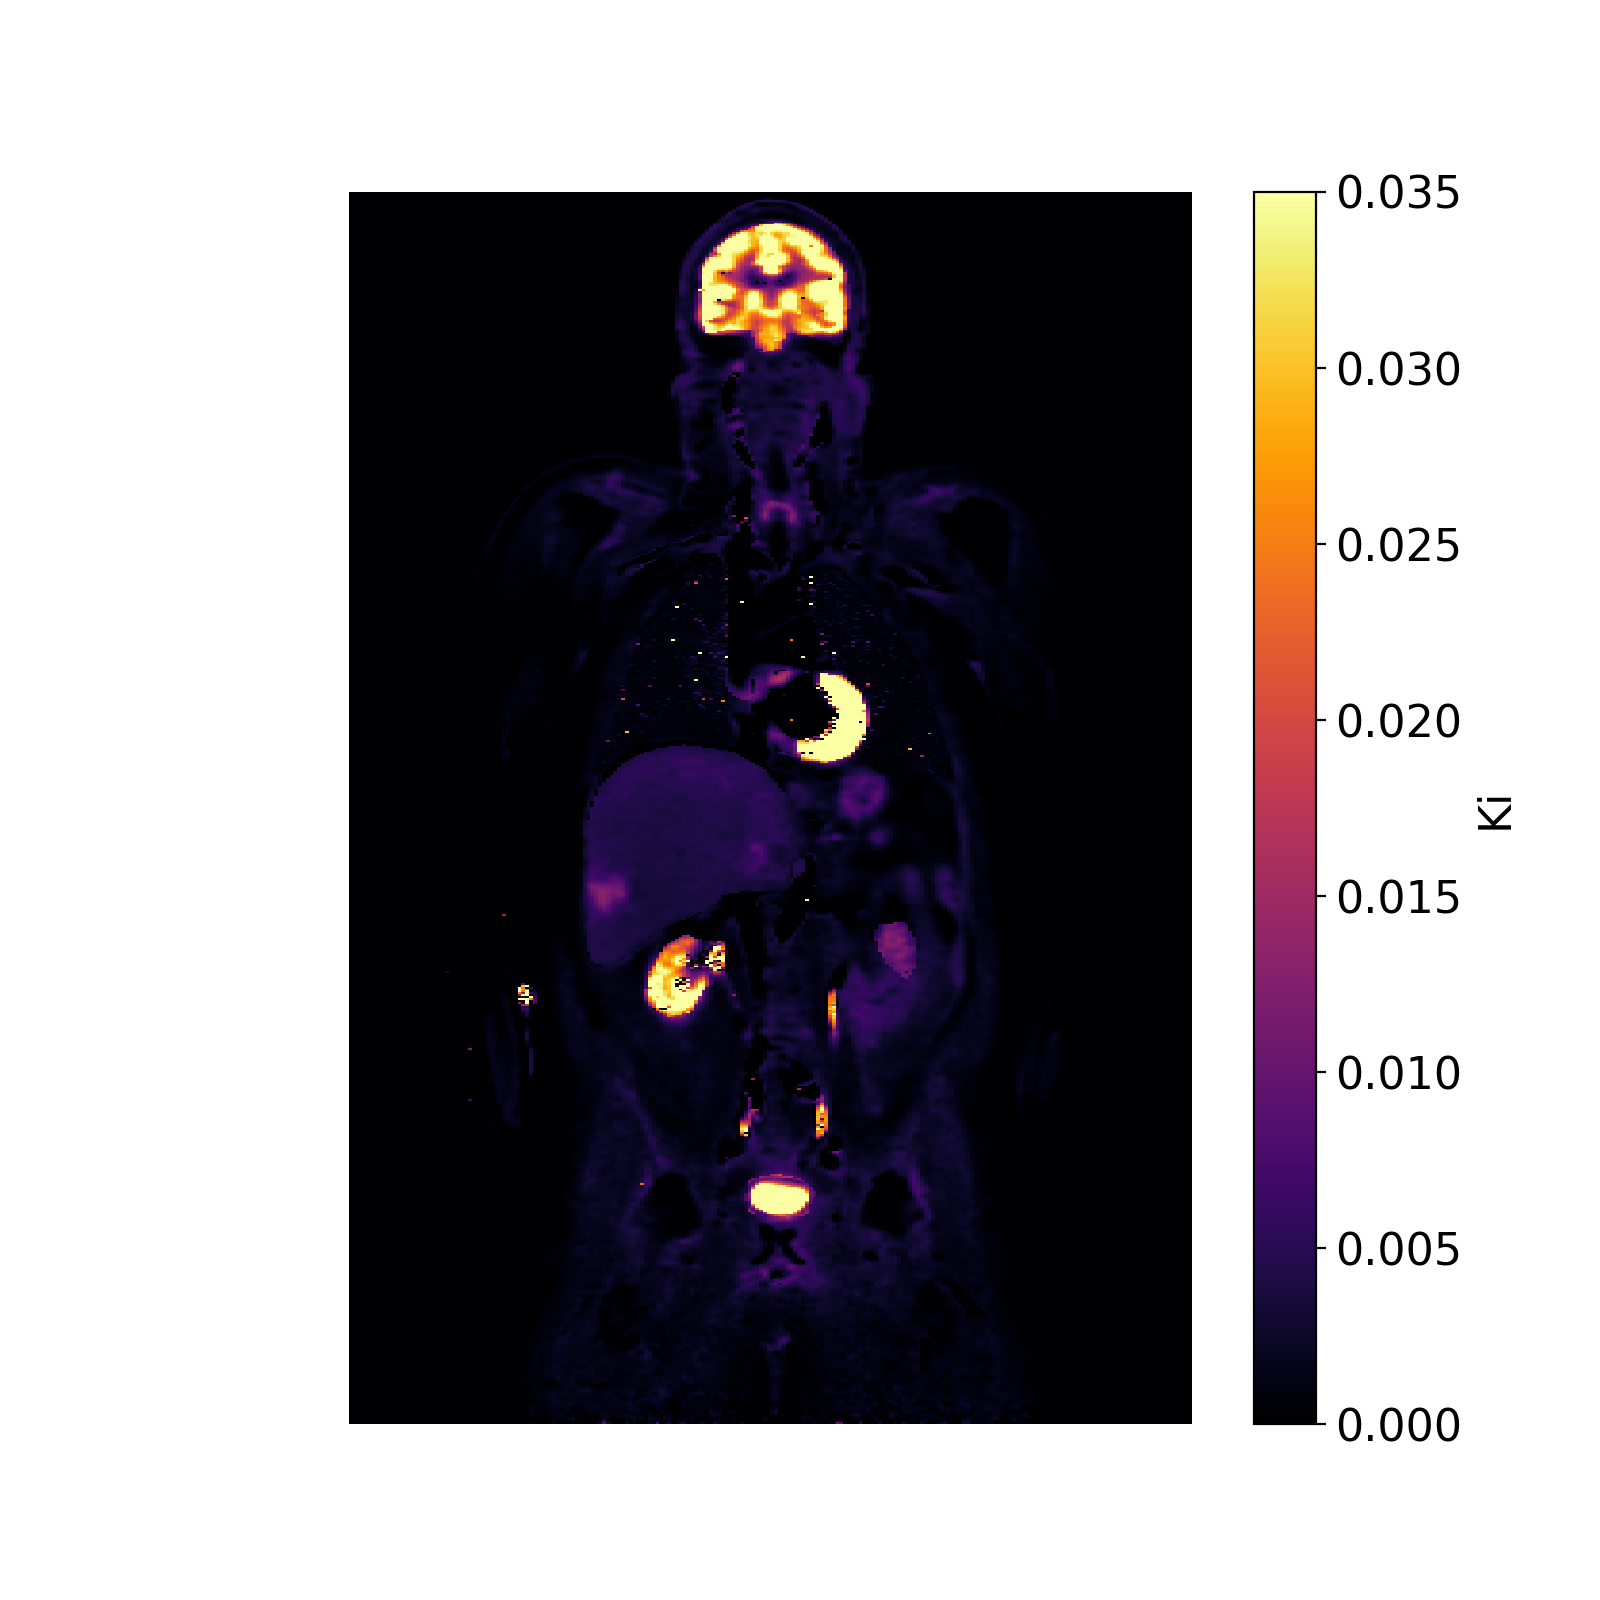

In [4]:
## Imaging
parameter_name = "Ki"
statistics = estimates[:,0]
parametric_map_interactive(statistics, mask_slice, spacing, parameter_name)

In [5]:
data = pd.read_hdf('./Example_Data/P001_PET_incl_bones_coronal_116_denoised_adjusted.h5')
data.head()

,Frame duration (min),Time (min),AIF (Bq/mL),0,1,2,3,4,5,6,...,83598,83599,83600,83601,83602,83603,83604,83605,83606,83607
0,0.083333,0.041667,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.192024e-14,1.340995e-14,2.278824e-14,2.710467e-14,-8.862465e-14,1.970037e-13,8.778456e-14,2.644892e-14,0.0,-1.218055e-14
1,0.083333,0.125000,0.000000,5.755824e-13,1.021453e-12,1.020660e-12,3.763675e-13,2.144042e-13,-1.036020e-13,-7.308081e-29,...,-2.546839e-26,-1.672897e-26,-2.345301e-26,-4.412451e-26,-1.539965e-14,-5.573205e-26,-4.306089e-26,-1.619253e-13,0.0,-1.215900e-25
2,0.083333,0.208333,0.062806,2.318185e+01,3.725228e+01,9.489522e-14,1.020121e-13,1.761865e+02,1.649488e+02,2.328958e+02,...,1.047425e-14,3.931600e-15,3.169076e-14,-1.010574e-13,2.955177e-12,-5.994685e-13,1.770942e-14,-5.859731e-14,0.0,4.286617e-14
3,0.083333,0.291667,15.824850,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,3.589281e-14,-7.073158e-14,1.377134e-13,1.139535e-13,3.025412e-11,8.374897e-27,6.068606e-14,5.577761e-13,0.0,-2.284994e-13
4,0.083333,0.375000,401.781070,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.402059e-12,1.612470e-12,1.217779e-12,1.570048e-11,-5.359723e-11,-1.344931e-11,4.061301e-12,2.557243e-11,0.0,3.766472e-12


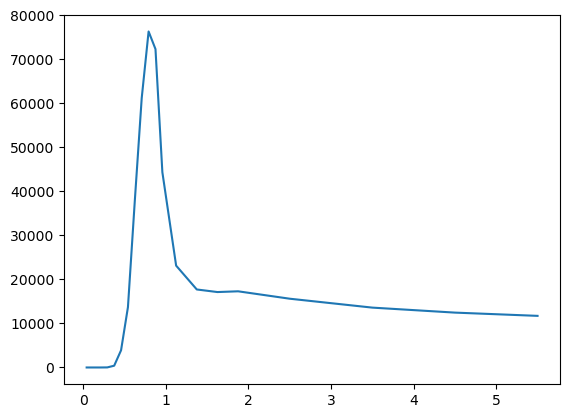

In [6]:
plt.plot(data.iloc[:,1], data.iloc[:,2])

In [12]:
data.iloc[:,2].values

array([0.0000000e+00, 0.0000000e+00, 6.2806260e-02, 1.5824850e+01,
       4.0178107e+02, 3.9083926e+03, 1.3713291e+04, 3.7946938e+04,
       6.1188816e+04, 7.6316790e+04, 7.2316390e+04, 4.4348668e+04,
       2.3132326e+04, 1.7718340e+04, 1.7130725e+04, 1.7301650e+04,
       1.5618752e+04, 1.3596492e+04, 1.2462261e+04, 1.1723953e+04,
       1.1173632e+04, 1.0648642e+04, 1.0134904e+04, 9.6001090e+03,
       9.1478360e+03, 8.7648670e+03, 8.4963260e+03, 8.2226470e+03,
       7.8587104e+03, 7.6095060e+03, 7.4196953e+03, 7.0765740e+03,
       6.7047790e+03, 6.2369946e+03, 6.0175950e+03])

In [8]:
Katya = pd.read_csv('/Users/golfgti/Desktop/Data_from_RNSH/35frame_IDIFs.csv')

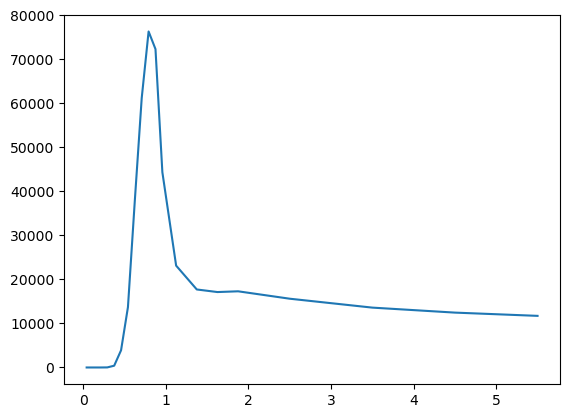

In [10]:
plt.plot(Katya.iloc[:20,0], Katya.iloc[:20,8])

In [11]:
data.iloc[:,2] = Katya.iloc[:,8]

In [13]:
data.to_hdf('P001_PET_incl_bones_coronal_116_denoised_adjusted.h5', key = "data", index = False, complevel = 9) 

/var/folders/_r/8sz_yn7d77q0mb885nkytvch0000gn/T/ipykernel_1871/2824144601.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->axis0] [items->None]

  data.to_hdf('P001_PET_incl_bones_coronal_116_denoised_adjusted.h5', key = "data", index = False, complevel = 9)
/var/folders/_r/8sz_yn7d77q0mb885nkytvch0000gn/T/ipykernel_1871/2824144601.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_items] [items->None]

  data.to_hdf('P001_PET_incl_bones_coronal_116_denoised_adjusted.h5', key = "data", index = False, complevel = 9)
